In [11]:
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path
from pickle import load

import matplotlib as mpl

mpl.rcParams.update({
    # Use LaTeX
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Lines
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 1,

    # Ticks
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Save figures
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


In [12]:
DATA_DIR = Path('data')
FULL_RESULTS_PATH = DATA_DIR / 'charge_stability.pkl'
LOG_FILE = DATA_DIR / 'charge_stability.log'
CHECKPOINT_GLOB = 'charge_stability_runs_*.pkl'


def load_pickle_stream(path):
    records = []
    with path.open('rb') as f:
        while True:
            try:
                records.append(load(f))
            except EOFError:
                break
            except Exception as exc:
                print(f'Stopped reading {path} after a partial/corrupt record: {exc}')
                break
    return records


def load_full_results(path):
    if not path.exists():
        return {'metadata': {}, 'runs': [], 'charge_stability': {}}

    with path.open('rb') as f:
        return load(f)


def newest_checkpoint_path(data_dir=DATA_DIR):
    checkpoints = list(data_dir.glob(CHECKPOINT_GLOB))
    if not checkpoints:
        return None
    return max(checkpoints, key=lambda p: p.stat().st_mtime)


def metadata_checkpoint_path(metadata):
    checkpoint_file = metadata.get('checkpoint_file')
    if not checkpoint_file:
        return None

    path = Path(checkpoint_file)
    if not path.is_absolute():
        path = Path.cwd() / path

    return path if path.exists() else None


def choose_checkpoint_path(metadata, full_results_path=FULL_RESULTS_PATH):
    latest_path = newest_checkpoint_path()
    metadata_path = metadata_checkpoint_path(metadata)

    if latest_path is None:
        return metadata_path
    if metadata_path is None:
        return latest_path
    if not full_results_path.exists():
        return latest_path

    # If a run is in progress, the append-only checkpoint is newer than the last
    # full snapshot and contains the points after the snapshot interval.
    if latest_path.stat().st_mtime > full_results_path.stat().st_mtime:
        return latest_path

    return metadata_path


def load_checkpoint(path):
    if path is None or not path.exists():
        return {}, {}, None

    header = None
    runs_by_grid_point = {}

    for record in load_pickle_stream(path):
        if record.get('kind') == 'header':
            header = record
        elif record.get('kind') == 'run':
            runs_by_grid_point[(int(record['i']), int(record['j']))] = record['run']

    sweep_config = header.get('sweep_config', {}) if header else {}
    sweep_hash = header.get('sweep_hash') if header else None
    return runs_by_grid_point, sweep_config, sweep_hash


def voltage_grid_from_sources(metadata, sweep_config, full_results, checkpoint_runs):
    if 'voltage_grid' in metadata:
        return np.asarray(metadata['voltage_grid'], dtype=float)
    if 'voltages' in sweep_config:
        return np.asarray(sweep_config['voltages'], dtype=float)

    voltages = []
    for run in full_results.get('runs', []):
        voltages.extend([run['vL'], run['vR']])
    for run in checkpoint_runs.values():
        voltages.extend([run['vL'], run['vR']])

    if not voltages:
        raise ValueError('No voltage grid found in metadata or runs.')

    return np.asarray(sorted(set(np.round(voltages, 15))), dtype=float)


def infer_grid_key(run, voltage_grid):
    vL = float(run['vL'])
    vR = float(run['vR'])
    i = int(np.argmin(np.abs(voltage_grid - vL)))
    j = int(np.argmin(np.abs(voltage_grid - vR)))
    return i, j


def runs_from_full_snapshot(full_results, voltage_grid):
    runs_by_grid_point = {}
    for run in full_results.get('runs', []):
        runs_by_grid_point[infer_grid_key(run, voltage_grid)] = run
    return runs_by_grid_point


def effective_units_to_mev(metadata, sweep_config):
    # Prefer the tolerances written by charge_stability.py: e_conv is the number
    # of effective units corresponding to eV_error eV.
    eV_error = metadata.get('eV_error_tolerance', sweep_config.get('eV_error'))
    e_conv = metadata.get('e_conv_tolerance_effective_units', sweep_config.get('e_conv'))
    if eV_error is not None and e_conv is not None:
        return 1e3 * float(eV_error) / float(e_conv)

    if 'effective_units_reference_energy' in metadata:
        electron_charge = 1.602176634e-19
        return 1e3 * float(metadata['effective_units_reference_energy']) / electron_charge

    raise ValueError('Cannot convert energy to meV: missing energy conversion metadata.')


def point_result(run, n_electrons):
    points = run.get('points', {})
    return points.get(n_electrons, points.get(str(n_electrons)))


full_results = load_full_results(FULL_RESULTS_PATH)
metadata = dict(full_results.get('metadata', {}))
checkpoint_path = choose_checkpoint_path(metadata)
checkpoint_runs, sweep_config, checkpoint_sweep_hash = load_checkpoint(checkpoint_path)

# If the selected checkpoint belongs to a newer sweep than the full snapshot,
# use the checkpoint as the source of completed points and use the full snapshot
# only for shared metadata such as the effective energy scale.
full_sweep_hash = metadata.get('checkpoint_sweep_hash')
checkpoint_is_newer_than_full = (
    checkpoint_path is not None
    and FULL_RESULTS_PATH.exists()
    and checkpoint_path.stat().st_mtime > FULL_RESULTS_PATH.stat().st_mtime
)
use_full_runs = not (
    checkpoint_sweep_hash
    and (
        (full_sweep_hash and checkpoint_sweep_hash != full_sweep_hash)
        or (not full_sweep_hash and checkpoint_is_newer_than_full)
    )
)

voltage_grid_v = voltage_grid_from_sources(metadata, sweep_config, full_results if use_full_runs else {}, checkpoint_runs)
full_runs = runs_from_full_snapshot(full_results, voltage_grid_v) if use_full_runs else {}

runs_by_grid_point = dict(full_runs)
runs_by_grid_point.update(checkpoint_runs)

if 'voltage_grid' not in metadata:
    metadata['voltage_grid'] = [float(v) for v in voltage_grid_v]
if checkpoint_path is not None:
    metadata['checkpoint_file'] = str(checkpoint_path)
if checkpoint_sweep_hash is not None:
    metadata['checkpoint_sweep_hash'] = checkpoint_sweep_hash

charge_stability = {
    'metadata': metadata,
    'runs': [runs_by_grid_point[key] for key in sorted(runs_by_grid_point)],
    'charge_stability': {
        key: (int(run['n_electrons']), float(run['energy']))
        for key, run in sorted(runs_by_grid_point.items())
    },
    'runs_by_grid_point': runs_by_grid_point,
}

energy_to_mev = effective_units_to_mev(metadata, sweep_config)
voltage_grid_mV = voltage_grid_v * 1e3
log = LOG_FILE.read_text().splitlines() if LOG_FILE.exists() else []

print(f"Loaded {len(full_runs)} full-snapshot points and {len(checkpoint_runs)} checkpoint points.")
print(f"Using {len(runs_by_grid_point)} total completed points.")
print(f"Checkpoint: {checkpoint_path}")
print(f"1 effective energy unit = {energy_to_mev:.6g} meV")


Loaded 1490 full-snapshot points and 1490 checkpoint points.
Using 1490 total completed points.
Checkpoint: /home/leander/Documents/PhD/Research_Projects/QDots/charge_stability_Leburton/data/charge_stability_runs_4e55be5a9112.pkl
1 effective energy unit = 0.454923 meV


In [13]:
if charge_stability['charge_stability']:
    list(charge_stability['charge_stability'].items())[-1]
else:
    'No completed voltage points yet.'


In [14]:
def empty_grid():
    return np.full((len(voltage_grid_v), len(voltage_grid_v)), np.nan)


def symmetric_grid(values_by_grid_point):
    grid = empty_grid()
    for (i, j), value in values_by_grid_point.items():
        grid[j, i] = value
        if i != j:
            grid[i, j] = value
    return grid


def stable_charge_grid(charge_stability):
    return symmetric_grid({
        key: n
        for key, (n, energy) in charge_stability['charge_stability'].items()
    })


def stable_energy_grid_mev(charge_stability):
    return symmetric_grid({
        key: energy * energy_to_mev
        for key, (n, energy) in charge_stability['charge_stability'].items()
    })


def total_energy_grid_mev(n_electrons):
    values = {}
    for key, run in charge_stability['runs_by_grid_point'].items():
        result = point_result(run, n_electrons)
        if result is not None:
            values[key] = float(result['energy']) * energy_to_mev
    return symmetric_grid(values)


def completed_voltage_extent(grid):
    valid_j, valid_i = np.where(~np.isnan(grid))
    if valid_i.size == 0:
        raise ValueError('No completed points found for this plot.')
    imax = max(valid_i.max(), valid_j.max())
    return voltage_grid_mV[0], voltage_grid_mV[imax]


def plot_grid(grid, *, cmap, colorbar_label, title=None, discrete_bounds=None):
    masked = np.ma.masked_invalid(grid)
    x_min, x_max = completed_voltage_extent(grid)
    y_min, y_max = x_min, x_max

    fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=200)

    norm = None
    if discrete_bounds is not None:
        norm = mpl.colors.BoundaryNorm(discrete_bounds, cmap.N)

    im = ax.imshow(
        masked,
        origin='lower',
        extent=[voltage_grid_mV[0], voltage_grid_mV[-1], voltage_grid_mV[0], voltage_grid_mV[-1]],
        cmap=cmap,
        norm=norm,
        interpolation='nearest',
        aspect='equal',
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    if title is not None:
        ax.set_title(title)
    ax.set_xlabel(r'$V_L$ (mV)')
    ax.set_ylabel(r'$V_R$ (mV)')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    fig.tight_layout()
    return fig, ax


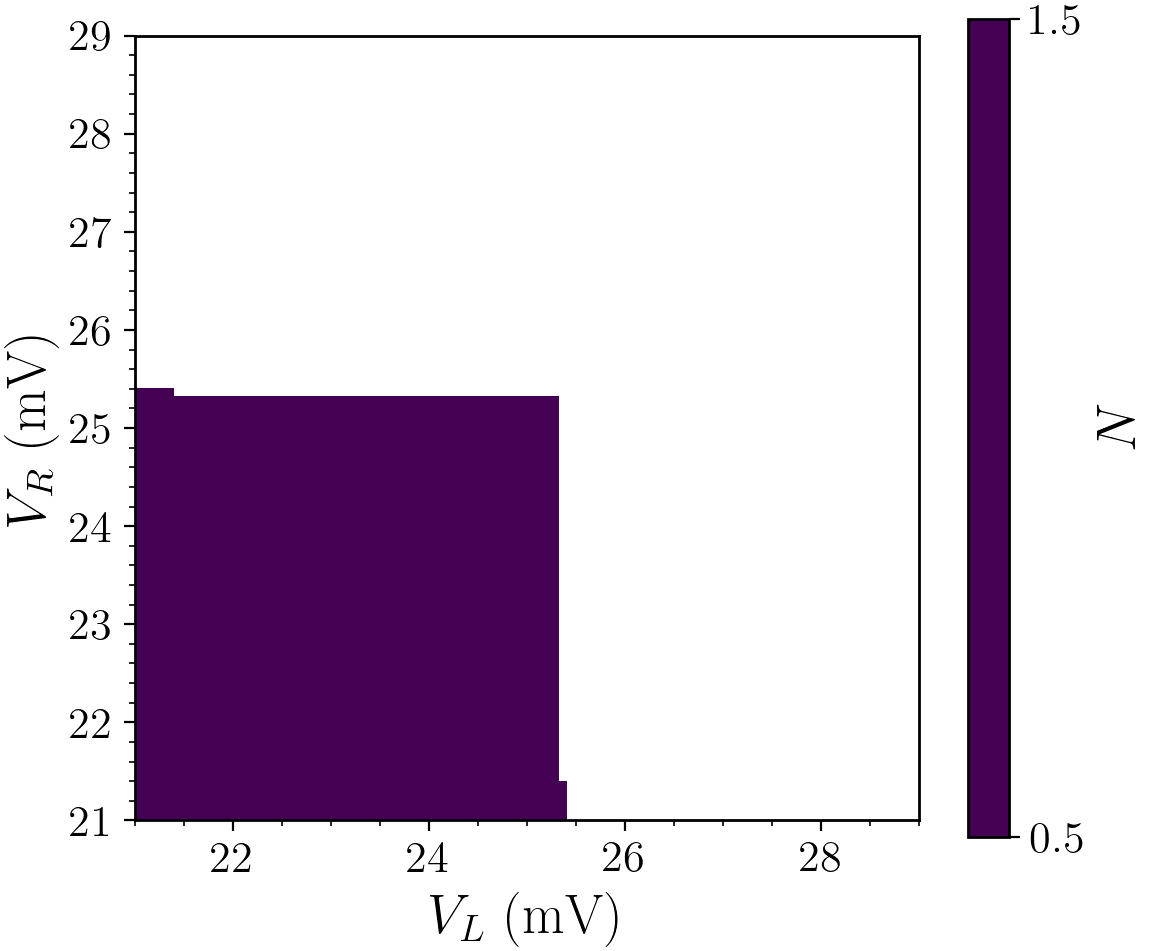

In [15]:
n_grid = stable_charge_grid(charge_stability)

valid_n = n_grid[~np.isnan(n_grid)].astype(int)
if valid_n.size == 0:
    raise ValueError('No charge-stability points found.')

n_min = valid_n.min()
n_max = valid_n.max()

cmap = plt.get_cmap('viridis', n_max - n_min + 1).copy()
cmap.set_bad('white')
bounds = np.arange(n_min - 0.5, n_max + 1.5, 1)

fig, ax = plot_grid(
    n_grid,
    cmap=cmap,
    colorbar_label=r'$N$',
    discrete_bounds=bounds,
)

if n_max > n_min:
    ax.contour(
        voltage_grid_mV,
        voltage_grid_mV,
        n_grid,
        levels=np.arange(n_min + 0.5, n_max + 0.5, 1),
        colors='k',
        linewidths=0.8,
    )

ax.set_xlim(voltage_grid_mV[0], voltage_grid_mV[-1])
ax.set_ylim(voltage_grid_mV[0], voltage_grid_mV[-1])
#fig.axes[-1].set_ticks(np.arange(n_min, n_max + 1))
plt.show()


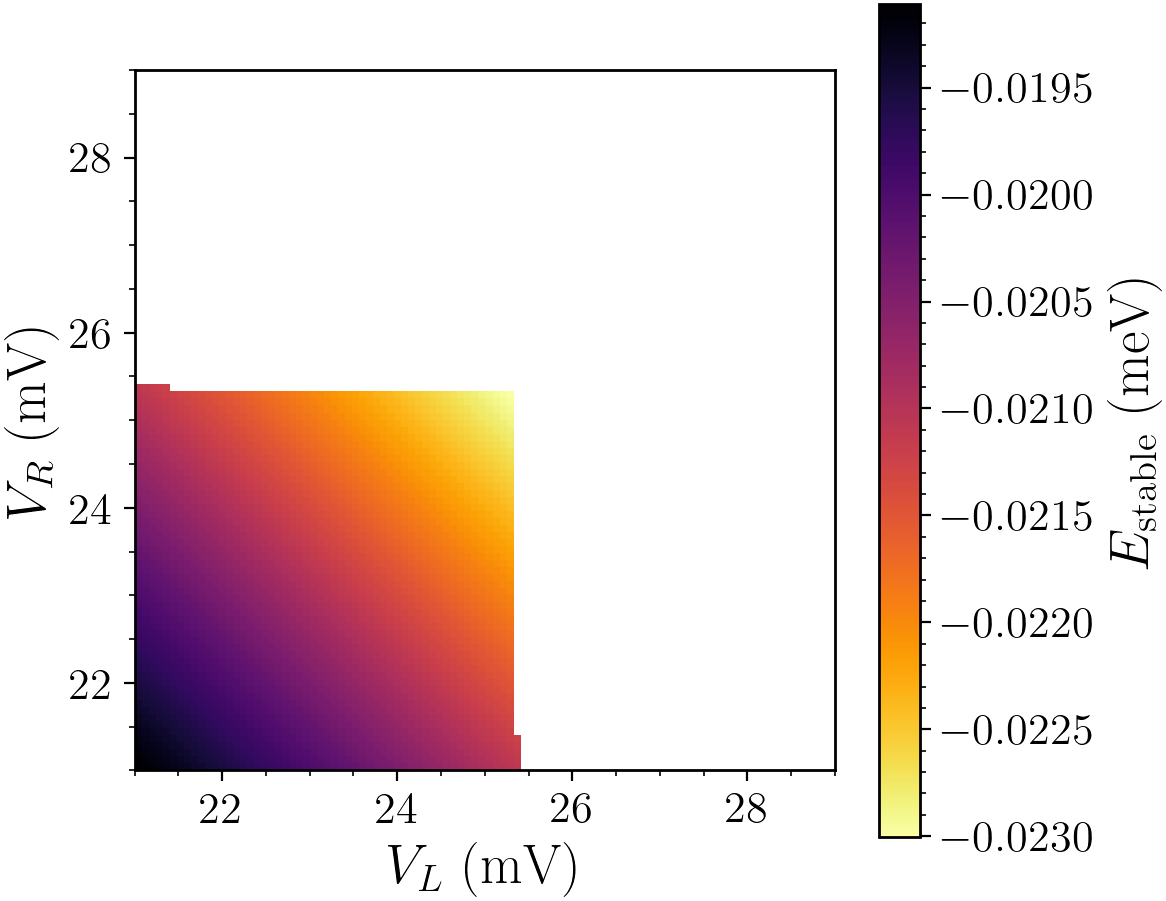

In [16]:
energy_grid = stable_energy_grid_mev(charge_stability)

cmap = plt.get_cmap('inferno_r').copy()
cmap.set_bad('white')

fig, ax = plot_grid(
    energy_grid,
    cmap=cmap,
    colorbar_label=r'$E_\mathrm{stable}$ (meV)',
)

ax.set_xlim(voltage_grid_mV[0], voltage_grid_mV[-1])
ax.set_ylim(voltage_grid_mV[0], voltage_grid_mV[-1])

plt.show()


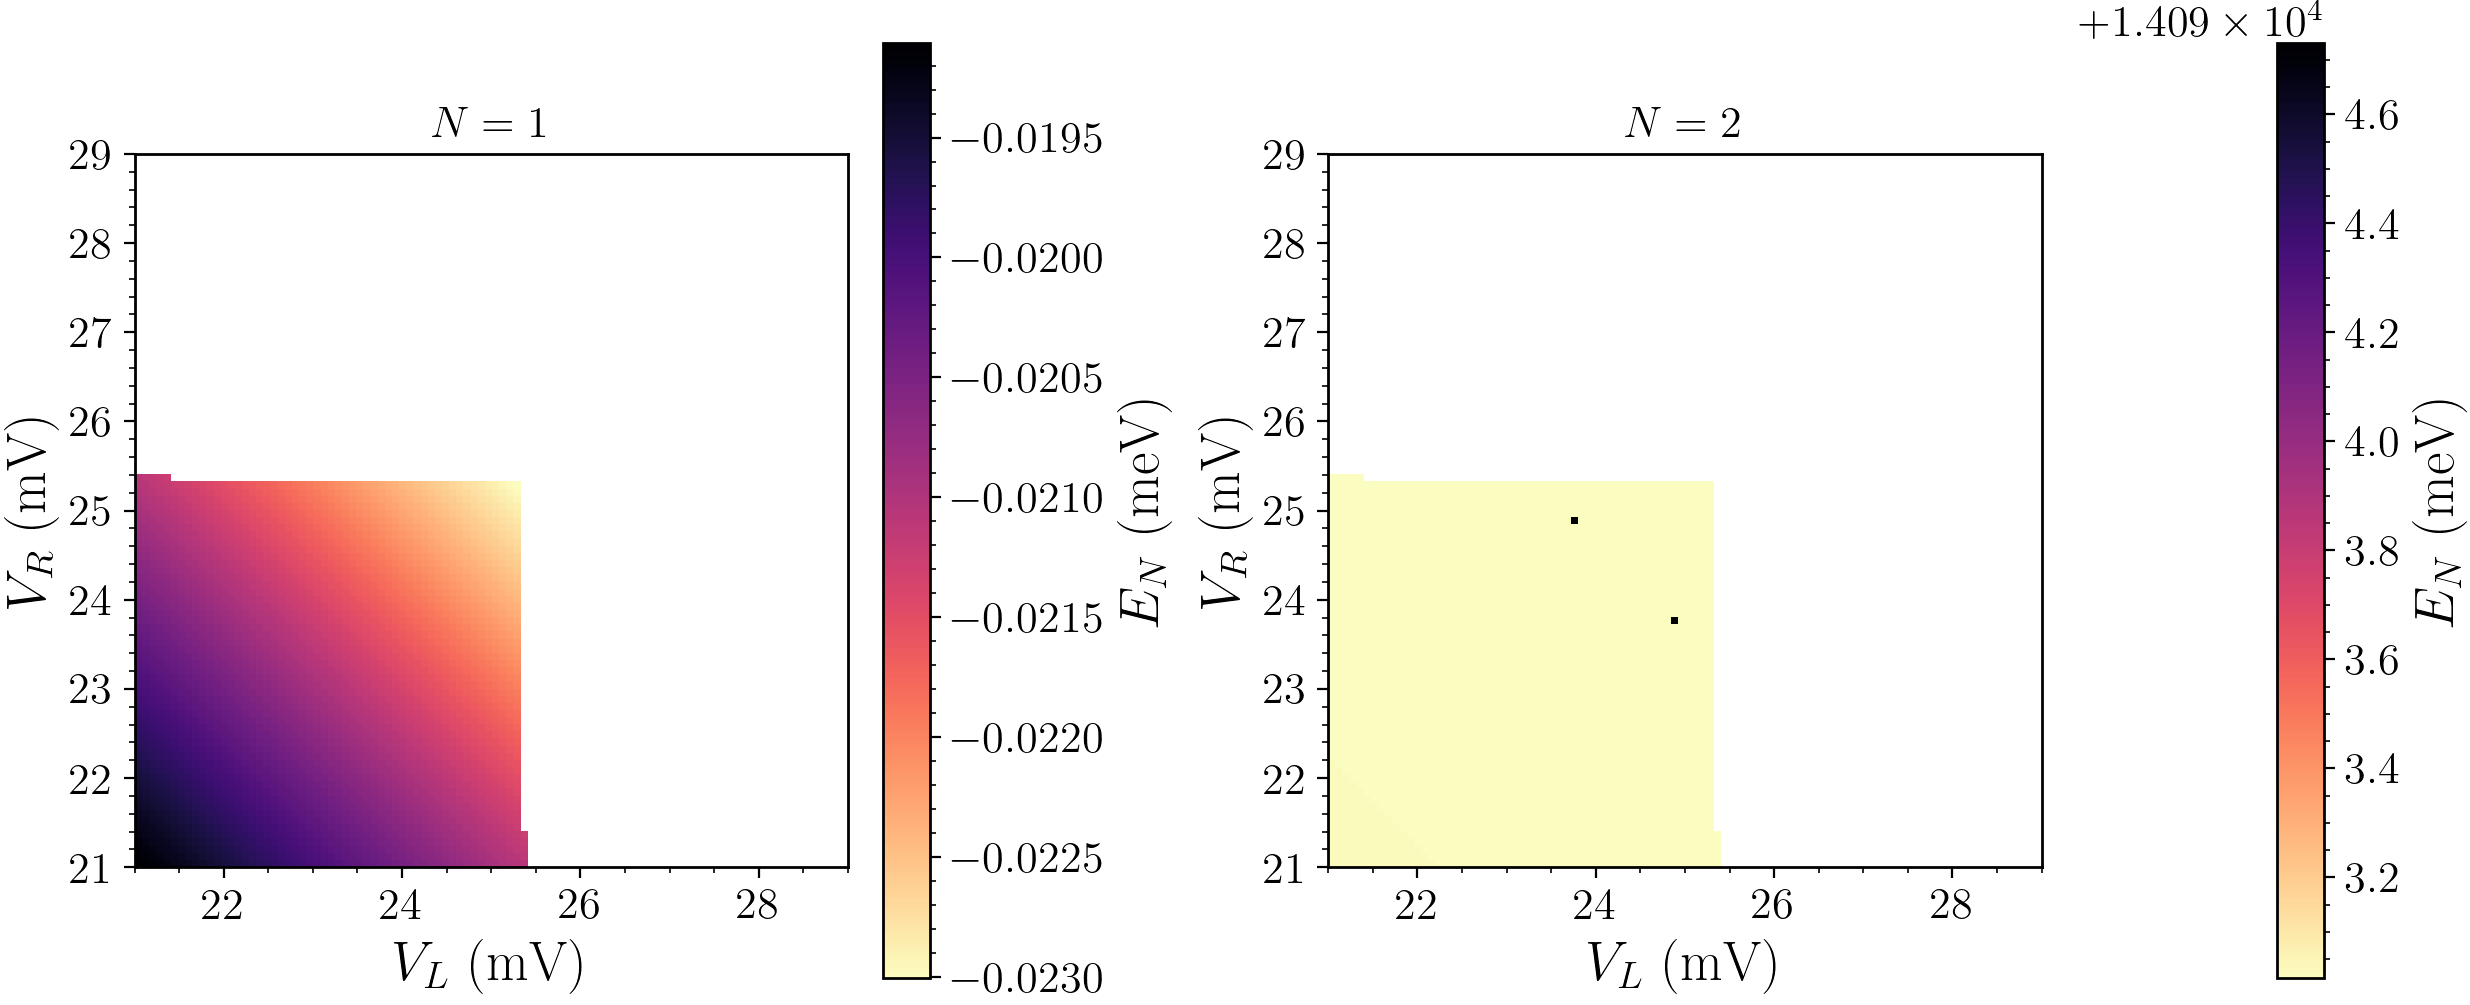

In [17]:
electron_counts = [1, 2]
fig, axes = plt.subplots(1, len(electron_counts), figsize=(12.4, 5.2), dpi=200, constrained_layout=True)

if len(electron_counts) == 1:
    axes = [axes]

for ax, n_electrons in zip(axes, electron_counts):
    grid = total_energy_grid_mev(n_electrons)
    if np.isnan(grid).all():
        ax.set_visible(False)
        print(f'No completed N={n_electrons} energies found.')
        continue

    x_min, x_max = completed_voltage_extent(grid)
    cmap = plt.get_cmap('magma_r').copy()
    cmap.set_bad('white')

    im = ax.imshow(
        np.ma.masked_invalid(grid),
        origin='lower',
        extent=[voltage_grid_mV[0], voltage_grid_mV[-1], voltage_grid_mV[0], voltage_grid_mV[-1]],
        cmap=cmap,
        interpolation='nearest',
        aspect='equal',
    )
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r'$E_N$ (meV)')

    ax.set_title(rf'$N={n_electrons}$')
    ax.set_xlabel(r'$V_L$ (mV)')
    ax.set_ylabel(r'$V_R$ (mV)')
    ax.set_xlim(voltage_grid_mV[0], voltage_grid_mV[-1])
    ax.set_ylim(voltage_grid_mV[0], voltage_grid_mV[-1])

plt.show()
